In [ ]:
import pandas as pd
import numpy as np
import os

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_path = os.path.join(base_dir, 'lstm_data.csv')
output_path = os.path.join(base_dir, 'lstm_data_cleaned_step1.csv')

print(f"Veri yükleniyor: {input_path}")

try:
    df = pd.read_csv(input_path)
    print(f" Veri başarıyla yüklendi. Orijinal Boyut: {df.shape}")
except FileNotFoundError:
    print(" HATA: Dosya bulunamadı! Lütfen Google Drive'ın mount edildiğinden ve yolun doğruluğundan emin olun.")
    df = pd.DataFrame() 
if not df.empty:
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])


    initial_count = len(df)
    df_clean = df[(df['speed'] >= 0) & (df['speed'] <= 200)].copy()
    speed_dropped = initial_count - len(df_clean)

   
    df_clean = df_clean[(df_clean['percent'] >= -50) & (df_clean['percent'] <= 50)]
    percent_dropped = (initial_count - speed_dropped) - len(df_clean)

    print("\n--- Temizlik Raporu ---")
    print(f"Hız (Speed) Filtresi ile Silinen: {speed_dropped} satır")
    print(f"Eğim (Percent) Filtresi ile Silinen: {percent_dropped} satır")
    print(f"Toplam Silinen Veri: {speed_dropped + percent_dropped} satır")
    print(f"Kalan Veri Boyutu: {df_clean.shape}")
    print(f"Veri Kaybı Oranı: %{((speed_dropped + percent_dropped)/initial_count)*100:.2f}")

    print("\n--- Temizlik Sonrası İstatistikler (Speed & Percent) ---")
    print(df_clean[['speed', 'percent']].describe())

    df_clean.to_csv(output_path, index=False)
    print(f"\n Temizlenmiş veri kaydedildi: {output_path}")

else:
    print("İşlem yapılamadı.")

Veri yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data.csv
 Veri başarıyla yüklendi. Orijinal Boyut: (293168, 13)

--- Temizlik Raporu ---
Hız (Speed) Filtresi ile Silinen: 60 satır
Eğim (Percent) Filtresi ile Silinen: 8185 satır
Toplam Silinen Veri: 8245 satır
Kalan Veri Boyutu: (284923, 12)
Veri Kaybı Oranı: %2.81

--- Temizlik Sonrası İstatistikler (Speed & Percent) ---
               speed        percent
count  284923.000000  284923.000000
mean       50.399500       3.507220
std        21.070595       6.874676
min         0.010000     -39.574244
25%        40.056881       0.210965
50%        53.643306       0.859374
75%        67.080711       3.319365
max       198.104137      49.995876

 Temizlenmiş veri kaydedildi: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_cleaned_step1.csv


In [ ]:
import pandas as pd
import numpy as np
import os

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_path = os.path.join(base_dir, 'lstm_data_cleaned_step1.csv')
output_path = os.path.join(base_dir, 'lstm_data_cleaned_step2.csv')

print(f"İşlenecek veri yükleniyor: {input_path}")

df = pd.read_csv(input_path)

print(" Bearing (Yön) verisi işleniyor...")

df['bearing'] = df['bearing'] % 360
df['bearing_rad'] = np.radians(df['bearing'])
df['bearing_sin'] = np.sin(df['bearing_rad'])
df['bearing_cos'] = np.cos(df['bearing_rad'])

print(" Anomali etiketleri düzenleniyor...")
df['anomaly_type'] = df['anomaly']
df['anomaly_binary'] = (df['anomaly'] > 0).astype(int)

print("\n--- Dönüşüm Sonrası Örnek Veri ---")
print(df[['bearing', 'bearing_sin', 'bearing_cos', 'anomaly_type', 'anomaly_binary']].head())

print("\n--- Anomali Dağılımı (Binary) ---")
print(df['anomaly_binary'].value_counts(normalize=True))

df.to_csv(output_path, index=False)
print(f"\n İşlenmiş veri kaydedildi: {output_path}")

İşlenecek veri yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_cleaned_step1.csv
 Bearing (Yön) verisi işleniyor...
 Anomali etiketleri düzenleniyor...

--- Dönüşüm Sonrası Örnek Veri ---
      bearing  bearing_sin  bearing_cos  anomaly_type  anomaly_binary
0  339.125888    -0.356316     0.934366             0               0
1  337.141667    -0.388454     0.921468             0               0
2  339.402443    -0.351802     0.936075             0               0
3  336.849884    -0.393142     0.919478             0               0
4  339.398462    -0.351867     0.936050             0               0

--- Anomali Dağılımı (Binary) ---
anomaly_binary
0    0.929911
1    0.070089
Name: proportion, dtype: float64

 İşlenmiş veri kaydedildi: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_cleaned_step2.csv


In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.preprocessing import MinMaxScaler, StandardScaler

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_path = os.path.join(base_dir, 'lstm_data_cleaned_step2.csv')
output_path = os.path.join(base_dir, 'lstm_data_normalized.csv')
scaler_path = os.path.join(base_dir, 'scalers.pkl')

print(f"Veri okunuyor: {input_path}")
df = pd.read_csv(input_path)


scaler_speed = MinMaxScaler()
df['speed_norm'] = scaler_speed.fit_transform(df[['speed']])

scaler_accel = StandardScaler()
df['accel_norm'] = scaler_accel.fit_transform(df[['accel']])

scalers = {
    'scaler_speed': scaler_speed,
    'scaler_accel': scaler_accel
}
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)

print("Scaler nesneleri kaydedildi.")


print("\n--- Normalizasyon Sonrası İstatistikler ---")
print(df[['speed', 'speed_norm', 'accel', 'accel_norm']].describe())

df.to_csv(output_path, index=False)
print(f"\nNormalize edilmiş veri kaydedildi: {output_path}")

Veri okunuyor: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_cleaned_step2.csv
Scaler nesneleri kaydedildi.

--- Normalizasyon Sonrası İstatistikler ---
               speed     speed_norm          accel    accel_norm
count  284923.000000  284923.000000  284923.000000  2.849230e+05
mean       50.399500       0.254371       0.000049 -3.020623e-18
std        21.070595       0.106367       1.166864  1.000002e+00
min         0.010000       0.000000     -13.132741 -1.125479e+01
25%        40.056881       0.202161      -1.258499 -1.078575e+00
50%        53.643306       0.270747       0.621683  5.327405e-01
75%        67.080711       0.338580       0.882790  7.565091e-01
max       198.104137       1.000000      16.167210  1.385525e+01

Normalize edilmiş veri kaydedildi: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_normalized.csv


In [ ]:
import pandas as pd
import numpy as np
import os

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_path = os.path.join(base_dir, 'lstm_data_normalized.csv')
output_path = os.path.join(base_dir, 'lstm_sequences.npz') 

SEQUENCE_LENGTH = 50  
STEP_SIZE = 10        

print(f"Veri okunuyor: {input_path}")
df = pd.read_csv(input_path)

feature_cols = ['speed_norm', 'accel_norm', 'bearing_sin', 'bearing_cos']
target_col = 'anomaly_binary'
meta_cols = ['trip_id', 'segment_id', 'time']

X_list = []
y_list = []
meta_list = []

print("Sekanslar oluşturuluyor... (Bu işlem biraz sürebilir)")

grouped = df.groupby('trip_id')

for trip_id, group in grouped:
    group = group.sort_values('time')

    features = group[feature_cols].values
    targets = group[target_col].values
    metas = group[meta_cols].values

    num_samples = len(group)

    for i in range(0, num_samples - SEQUENCE_LENGTH + 1, STEP_SIZE):
        window_X = features[i : i + SEQUENCE_LENGTH]

        window_y = targets[i + SEQUENCE_LENGTH - 1]

        window_meta = metas[i + SEQUENCE_LENGTH - 1]

        X_list.append(window_X)
        y_list.append(window_y)
        meta_list.append(window_meta)

X_array = np.array(X_list)
y_array = np.array(y_list)
meta_array = np.array(meta_list)

print("\n--- Sekans Oluşturma Raporu ---")
print(f"Toplam Oluşturulan Sekans Sayısı: {len(y_array)}")
print(f"X Boyutu (Samples, TimeSteps, Features): {X_array.shape}")
print(f"y Boyutu (Targets): {y_array.shape}")
print(f"Meta Boyutu (Trip, Segment, Time): {meta_array.shape}")

unique, counts = np.unique(y_array, return_counts=True)
dist = dict(zip(unique, counts))
print(f"\nSınıf Dağılımı (0: Normal, 1: Anomali): {dist}")
if 1 in dist:
    print(f"Anomali Oranı: %{dist[1] / len(y_array) * 100:.2f}")
else:
    print("UYARI: Hiç anomali yakalanmadı! Step size veya veri setini kontrol et.")

# Kaydet
np.savez_compressed(output_path, X=X_array, y=y_array, meta=meta_array)
print(f"\nSekans verileri kaydedildi (.npz): {output_path}")

Veri okunuyor: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_data_normalized.csv
Sekanslar oluşturuluyor... (Bu işlem biraz sürebilir)

--- Sekans Oluşturma Raporu ---
Toplam Oluşturulan Sekans Sayısı: 28090
X Boyutu (Samples, TimeSteps, Features): (28090, 50, 4)
y Boyutu (Targets): (28090,)
Meta Boyutu (Trip, Segment, Time): (28090, 3)

Sınıf Dağılımı (0: Normal, 1: Anomali): {np.int64(0): np.int64(26105), np.int64(1): np.int64(1985)}
Anomali Oranı: %7.07

Sekans verileri kaydedildi (.npz): /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_sequences.npz


In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_path = os.path.join(base_dir, 'GNN_DATA.csv')
output_features_path = os.path.join(base_dir, 'gnn_node_features.npy')
output_mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
output_nodes_df_path = os.path.join(base_dir, 'gnn_unique_nodes.csv')

print(f"GNN verisi okunuyor: {input_path}")
df_gnn = pd.read_csv(input_path)
print(f"Orijinal Veri Boyutu: {df_gnn.shape}")



df_nodes = df_gnn.drop_duplicates(subset=['segment_id']).copy()
df_nodes = df_nodes.sort_values('segment_id').reset_index(drop=True)
print(f"Tekil Segment (Node) Sayısı: {len(df_nodes)}")

segment_to_idx = {seg_id: idx for idx, seg_id in enumerate(df_nodes['segment_id'])}
idx_to_segment = {idx: seg_id for seg_id, idx in segment_to_idx.items()}


df_nodes['length_log'] = np.log1p(df_nodes['length_meters'])

num_cols = ['length_log', 'max_speed', 'rarity_score', 'betweenness', 'closeness', 'node_degree', 'lanes']
scaler = MinMaxScaler()
num_features = scaler.fit_transform(df_nodes[num_cols])


ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
road_type_features = ohe.fit_transform(df_nodes[['road_type']])
road_type_names = ohe.get_feature_names_out(['road_type'])

binary_features = df_nodes[['tunnel', 'traffic_light']].values

node_features = np.hstack([num_features, binary_features, road_type_features])


print("\n--- Node Features Raporu ---")
print(f"Toplam Özellik Sayısı (Feature Dim): {node_features.shape[1]}")
print("Özellik Sırası (İlk 9 + Road Types):")
feature_names = num_cols + ['tunnel', 'traffic_light'] + list(road_type_names)
print(feature_names)

print(f"\nNode Features Matrisi Boyutu: {node_features.shape}")

np.save(output_features_path, node_features)
with open(output_mapping_path, 'wb') as f:
    pickle.dump(segment_to_idx, f)

df_nodes.to_csv(output_nodes_df_path, index=False)

print(f"\n Dosyalar kaydedildi:")
print(f"1. Node Features (.npy): {output_features_path}")
print(f"2. Mapping (.pkl): {output_mapping_path}")
print(f"3. Unique Nodes (.csv): {output_nodes_df_path}")

GNN verisi okunuyor: /content/drive/MyDrive/Colab Notebooks/veriseti/GNN_DATA.csv
Orijinal Veri Boyutu: (4678, 17)
Tekil Segment (Node) Sayısı: 4678

--- Node Features Raporu ---
Toplam Özellik Sayısı (Feature Dim): 17
Özellik Sırası (İlk 9 + Road Types):
['length_log', 'max_speed', 'rarity_score', 'betweenness', 'closeness', 'node_degree', 'lanes', 'tunnel', 'traffic_light', 'road_type_motorway', 'road_type_motorway_link', 'road_type_primary', 'road_type_primary_link', 'road_type_secondary', 'road_type_secondary_link', 'road_type_trunk', 'road_type_trunk_link']

Node Features Matrisi Boyutu: (4678, 17)

 Dosyalar kaydedildi:
1. Node Features (.npy): /content/drive/MyDrive/Colab Notebooks/veriseti/gnn_node_features.npy
2. Mapping (.pkl): /content/drive/MyDrive/Colab Notebooks/veriseti/segment_mapping.pkl
3. Unique Nodes (.csv): /content/drive/MyDrive/Colab Notebooks/veriseti/gnn_unique_nodes.csv


In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
import torch

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_nodes_path = os.path.join(base_dir, 'gnn_unique_nodes.csv')
input_mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
output_edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')

print(f"Node verisi okunuyor: {input_nodes_path}")
df_nodes = pd.read_csv(input_nodes_path)

with open(input_mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)


print("Kenar (Edge) bağlantıları kuruluyor...")


split_ids = df_nodes['osm_segment_id'].astype(str).str.split('-', expand=True)
df_nodes['start_node'] = split_ids[0]
df_nodes['end_node'] = split_ids[1]


start_node_map = {}

for idx, row in df_nodes.iterrows():
    s_node = row['start_node']
    if s_node not in start_node_map:
        start_node_map[s_node] = []
    start_node_map[s_node].append(idx) 

source_nodes = []
target_nodes = []

for idx, row in df_nodes.iterrows():
    e_node = row['end_node']

    if e_node in start_node_map:
        next_segments = start_node_map[e_node]

        for next_seg_idx in next_segments:
            # Segment(idx) -> Segment(next_seg_idx) bağlantısı var
            source_nodes.append(idx)
            target_nodes.append(next_seg_idx)

edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

# 4. Rapor ve Kayıt
print("\n--- Graf İstatistikleri ---")
print(f"Toplam Düğüm (Node): {len(df_nodes)}")
print(f"Toplam Kenar (Edge): {edge_index.shape[1]}")
print(f"Ortalama Bağlantı (Degree): {edge_index.shape[1] / len(df_nodes):.2f}")
print(f"Edge Index Boyutu: {edge_index.shape}")

unique_connected_nodes = torch.unique(edge_index)
print(f"Bağlantısı Olan Düğüm Sayısı: {len(unique_connected_nodes)}")
print(f"İzole Düğüm Sayısı: {len(df_nodes) - len(unique_connected_nodes)}")

# Kaydet
torch.save(edge_index, output_edge_path)
print(f"\nEdge Index kaydedildi (.pt): {output_edge_path}")

Node verisi okunuyor: /content/drive/MyDrive/Colab Notebooks/veriseti/gnn_unique_nodes.csv
Kenar (Edge) bağlantıları kuruluyor...

--- Graf İstatistikleri ---
Toplam Düğüm (Node): 4678
Toplam Kenar (Edge): 53660
Ortalama Bağlantı (Degree): 11.47
Edge Index Boyutu: torch.Size([2, 53660])
Bağlantısı Olan Düğüm Sayısı: 4678
İzole Düğüm Sayısı: 0

Edge Index kaydedildi (.pt): /content/drive/MyDrive/Colab Notebooks/veriseti/gnn_edge_index.pt


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split

# 1. Dosya Yolları
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
input_seq_path = os.path.join(base_dir, 'lstm_sequences.npz')
output_split_path = os.path.join(base_dir, 'dataset_splits.npz')

print(f"Sekans verisi yükleniyor: {input_seq_path}")
data = np.load(input_seq_path)
X = data['X']
y = data['y']
meta = data['meta'] 
unique_trips = np.unique(meta[:, 0])
print(f"Toplam Sürüş (Trip) Sayısı: {len(unique_trips)}")

train_trips, temp_trips = train_test_split(unique_trips, test_size=0.30, random_state=42, shuffle=True)

val_trips, test_trips = train_test_split(temp_trips, test_size=0.50, random_state=42, shuffle=True)

print(f"Train Trips: {len(train_trips)}")
print(f"Val Trips: {len(val_trips)}")
print(f"Test Trips: {len(test_trips)}")


train_mask = np.isin(meta[:, 0], train_trips)
val_mask = np.isin(meta[:, 0], val_trips)
test_mask = np.isin(meta[:, 0], test_trips)

X_train, y_train, meta_train = X[train_mask], y[train_mask], meta[train_mask]
X_val, y_val, meta_val = X[val_mask], y[val_mask], meta[val_mask]
X_test, y_test, meta_test = X[test_mask], y[test_mask], meta[test_mask]

print("\n--- Split Sonuçları ---")
print(f"Train Seti: {X_train.shape[0]} sekans (Anomali Oranı: %{y_train.mean()*100:.2f})")
print(f"Val Seti:   {X_val.shape[0]} sekans (Anomali Oranı: %{y_val.mean()*100:.2f})")
print(f"Test Seti:  {X_test.shape[0]} sekans (Anomali Oranı: %{y_test.mean()*100:.2f})")

np.savez_compressed(output_split_path,
                    X_train=X_train, y_train=y_train, meta_train=meta_train,
                    X_val=X_val, y_val=y_val, meta_val=meta_val,
                    X_test=X_test, y_test=y_test, meta_test=meta_test)

print(f"\n Veri setleri ayrıldı ve kaydedildi: {output_split_path}")

Sekans verisi yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/lstm_sequences.npz
Toplam Sürüş (Trip) Sayısı: 90
Train Trips: 63
Val Trips: 13
Test Trips: 14

--- Split Sonuçları ---
Train Seti: 19255 sekans (Anomali Oranı: %7.90)
Val Seti:   4036 sekans (Anomali Oranı: %7.58)
Test Seti:  4799 sekans (Anomali Oranı: %3.27)

 Veri setleri ayrıldı ve kaydedildi: /content/drive/MyDrive/Colab Notebooks/veriseti/dataset_splits.npz


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")

class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # batch_first=True -> Girdi: (Batch, Seq_Len, Features)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)


        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        out, (hidden, cell) = self.lstm(x)


        last_time_step = out[:, -1, :]  # Shape: (Batch, Hidden_Dim)

        embedding = self.dropout(last_time_step)

        logits = self.fc(embedding)
        probs = self.sigmoid(logits)

        return probs, embedding

INPUT_DIM = 4   # [speed, accel, sin, cos]
HIDDEN_DIM = 128
SEQ_LEN = 50
BATCH_SIZE = 32

model = LSTMModel(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
print("\nModel Mimarisi:")
print(model)

# Rastgele bir tensör oluştur (Batch=32, Seq=50, Feat=4)
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN, INPUT_DIM).to(device)

# Modeli çalıştır
dummy_prob, dummy_emb = model(dummy_input)

print("\n--- Boyut Kontrolü (Sanity Check) ---")
print(f"Girdi Boyutu: {dummy_input.shape}")
print(f"Çıktı Olasılık Boyutu (Batch, 1): {dummy_prob.shape}")
print(f"Çıktı Embedding Boyutu (Batch, Hidden): {dummy_emb.shape}")

if dummy_prob.shape == (BATCH_SIZE, 1) and dummy_emb.shape == (BATCH_SIZE, HIDDEN_DIM):
    print(" LSTM Mimarisi başarıyla doğrulandı.")
else:
    print(" HATA: Boyutlarda uyuşmazlık var!")

Kullanılan Cihaz: cuda

Model Mimarisi:
LSTMModel(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

--- Boyut Kontrolü (Sanity Check) ---
Girdi Boyutu: torch.Size([32, 50, 4])
Çıktı Olasılık Boyutu (Batch, 1): torch.Size([32, 1])
Çıktı Embedding Boyutu (Batch, Hidden): torch.Size([32, 128])
 LSTM Mimarisi başarıyla doğrulandı.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


try:
    from torch_geometric.nn import GATConv, global_mean_pool
except ImportError:
    print("Torch Geometric bulunamadı. Kuruluyor...")
    import os
    os.system('pip install -q torch-geometric')
    from torch_geometric.nn import GATConv, global_mean_pool

# Cihaz Tanımlama
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GATModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GATModel, self).__init__()

        self.dropout_ratio = dropout


        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)


        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)


        self.fc = nn.Linear(output_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout_ratio, training=self.training)

        x = self.conv2(x, edge_index)
 

        embedding = x

        logits = self.fc(embedding)
        probs = self.sigmoid(logits)

        return probs, embedding


NUM_NODE_FEATURES = 17 
HIDDEN_DIM = 32
OUTPUT_DIM = 64 
HEADS = 2

gnn_model = GATModel(
    num_node_features=NUM_NODE_FEATURES,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_heads=HEADS
).to(device)

print("\nGNN Model Mimarisi:")
print(gnn_model)


dummy_x = torch.randn(10, NUM_NODE_FEATURES).to(device)
dummy_edge_index = torch.randint(0, 10, (2, 20)).to(device)

class DummyData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index

dummy_data = DummyData(dummy_x, dummy_edge_index)

gnn_probs, gnn_emb = gnn_model(dummy_data)

print("\n--- Boyut Kontrolü (Sanity Check) ---")
print(f"Girdi Node Features: {dummy_x.shape}")
print(f"Çıktı Olasılık Boyutu (Node, 1): {gnn_probs.shape}")
print(f"Çıktı Embedding Boyutu (Node, Emb_Dim): {gnn_emb.shape}")

if gnn_probs.shape == (10, 1) and gnn_emb.shape == (10, OUTPUT_DIM):
    print("GNN Mimarisi başarıyla doğrulandı.")
else:
    print("HATA: Boyutlarda uyuşmazlık var!")

Torch Geometric bulunamadı. Kuruluyor...

GNN Model Mimarisi:
GATModel(
  (conv1): GATConv(17, 32, heads=2)
  (conv2): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

--- Boyut Kontrolü (Sanity Check) ---
Girdi Node Features: torch.Size([10, 17])
Çıktı Olasılık Boyutu (Node, 1): torch.Size([10, 1])
Çıktı Embedding Boyutu (Node, Emb_Dim): torch.Size([10, 64])
GNN Mimarisi başarıyla doğrulandı.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridAnomalyModel(nn.Module):
    def __init__(self, lstm_model, gnn_model, lstm_emb_dim=128, gnn_emb_dim=64, fusion_dim=64):
        super(HybridAnomalyModel, self).__init__()

        self.lstm_model = lstm_model
        self.gnn_model = gnn_model

        self.project_lstm = nn.Linear(lstm_emb_dim, fusion_dim)
        self.project_gnn = nn.Linear(gnn_emb_dim, fusion_dim)


        self.attention_gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x_lstm, data_gnn, current_segment_indices):
        """
        x_lstm: (Batch, Seq_Len, Features) -> Araç hareket verisi
        data_gnn: PyG Data objesi -> Tüm yol ağı
        current_segment_indices: (Batch,) -> O an aracın hangi segmentte olduğu (Node Index)
        """

     
        _, emb_lstm = self.lstm_model(x_lstm)  # (Batch, 128)

  
        _, all_node_embs = self.gnn_model(data_gnn) # (Total_Nodes, 64)

        emb_gnn = all_node_embs[current_segment_indices] # (Batch, 64)

        proj_lstm = F.relu(self.project_lstm(emb_lstm)) # (Batch, 64)
        proj_gnn = F.relu(self.project_gnn(emb_gnn))    # (Batch, 64)

     
        concat_features = torch.cat([proj_lstm, proj_gnn], dim=1) # (Batch, 128)

        alpha = self.attention_gate(concat_features)

     
        fused_vector = (alpha * proj_lstm) + ((1 - alpha) * proj_gnn)

        prediction = self.classifier(fused_vector)

        return prediction, alpha  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lstm_part = LSTMModel(input_dim=4, hidden_dim=128).to(device)
gnn_part = GATModel(num_node_features=17, hidden_dim=32, output_dim=64).to(device)

hybrid_model = HybridAnomalyModel(lstm_part, gnn_part).to(device)

print("\nHibrit Model Mimarisi:")
print(hybrid_model)

BATCH_SIZE = 16
dummy_lstm_in = torch.randn(BATCH_SIZE, 50, 4).to(device)

class DummyData:
    def __init__(self):
        self.x = torch.randn(100, 17).to(device) # 100 node'lu bir graf
        self.edge_index = torch.randint(0, 100, (2, 200)).to(device)
dummy_gnn_data = DummyData()

dummy_indices = torch.randint(0, 100, (BATCH_SIZE,)).to(device)

# Çalıştır
pred, attn_weights = hybrid_model(dummy_lstm_in, dummy_gnn_data, dummy_indices)

print("\n--- Hibrit Boyut Kontrolü ---")
print(f"Tahmin Boyutu (Batch, 1): {pred.shape}")
print(f"Attention Ağırlık Boyutu (Batch, 1): {attn_weights.shape}")

if pred.shape == (BATCH_SIZE, 1):
    print(" Hibrit Model (Attention Fusion ile) başarıyla kuruldu.")
else:
    print(" HATA: Boyut uyuşmazlığı!")


Hibrit Model Mimarisi:
HybridAnomalyModel(
  (lstm_model): LSTMModel(
    (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
    (dropout): Dropout(p=0.2, inplace=False)
    (fc): Linear(in_features=128, out_features=1, bias=True)
    (sigmoid): Sigmoid()
  )
  (gnn_model): GATModel(
    (conv1): GATConv(17, 32, heads=2)
    (conv2): GATConv(64, 64, heads=1)
    (fc): Linear(in_features=64, out_features=1, bias=True)
    (sigmoid): Sigmoid()
  )
  (project_lstm): Linear(in_features=128, out_features=64, bias=True)
  (project_gnn): Linear(in_features=64, out_features=64, bias=True)
  (attention_gate): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
   

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import pickle
from sklearn.metrics import f1_score, accuracy_score

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 50
PATIENCE = 15  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
splits_path = os.path.join(base_dir, 'dataset_splits.npz')
mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')
node_feat_path = os.path.join(base_dir, 'gnn_node_features.npy')
model_save_path = os.path.join(base_dir, 'best_hybrid_model.pth')
best_f1_save_path = os.path.join(base_dir, 'best_f1_hybrid_model.pth')

print("Veriler yükleniyor...")

data = np.load(splits_path)
X_train, y_train, meta_train = data['X_train'], data['y_train'], data['meta_train']
X_val, y_val, meta_val = data['X_val'], data['y_val'], data['meta_val']

node_features = np.load(node_feat_path)
edge_index = torch.load(edge_path)

with open(mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)

class GNNData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index

gnn_data_tensor = GNNData(
    x=torch.tensor(node_features, dtype=torch.float).to(device),
    edge_index=edge_index.to(device)
)

def map_segments(meta_data, mapping):
    indices = []
    for seg_id in meta_data[:, 1]:
        if seg_id in mapping:
            indices.append(mapping[seg_id])
        else:
            indices.append(0)
    return np.array(indices)

print("Segment ID'leri Node Index'lerine dönüştürülüyor...")
train_node_indices = map_segments(meta_train, segment_to_idx)
val_node_indices = map_segments(meta_val, segment_to_idx)

class HybridDataset(Dataset):
    def __init__(self, X, y, node_indices):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
        self.node_indices = torch.tensor(node_indices, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.node_indices[idx]

train_dataset = HybridDataset(X_train, y_train, train_node_indices)
val_dataset = HybridDataset(X_val, y_val, val_node_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 5. Ağırlık Hesaplama
num_pos = np.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = num_neg / num_pos
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float).to(device)

print(f"Eğitim Seti: {len(X_train)} | Pozitif: {num_pos} | Negatif: {num_neg}")
print(f"Anomali Ağırlığı: {pos_weight:.2f}")

def weighted_bce_loss(output, target, weight):
    epsilon = 1e-7
    output = torch.clamp(output, epsilon, 1. - epsilon)
    loss = -1 * (weight * target * torch.log(output) + (1 - target) * torch.log(1 - output))
    return loss.mean()


optimizer = optim.Adam(hybrid_model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


print("\nEğitim Başlıyor (Accuracy ve Scheduler Eklendi)...")

best_val_loss = float('inf')
best_val_f1 = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    hybrid_model.train()
    train_loss = 0
    train_preds_list = []
    train_targets_list = []

    for x_batch, y_batch, idx_batch in train_loader:
        x_batch, y_batch, idx_batch = x_batch.to(device), y_batch.to(device), idx_batch.to(device)

        optimizer.zero_grad()
        preds, _ = hybrid_model(x_batch, gnn_data_tensor, idx_batch)
        loss = weighted_bce_loss(preds, y_batch, pos_weight_tensor)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        train_preds_list.extend(preds.detach().cpu().numpy())
        train_targets_list.extend(y_batch.detach().cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)

    train_pred_labels = (np.array(train_preds_list) > 0.5).astype(int)
    train_acc = accuracy_score(train_targets_list, train_pred_labels)
    train_f1 = f1_score(train_targets_list, train_pred_labels)

    hybrid_model.eval()
    val_loss = 0
    val_preds_list = []
    val_targets_list = []

    with torch.no_grad():
        for x_batch, y_batch, idx_batch in val_loader:
            x_batch, y_batch, idx_batch = x_batch.to(device), y_batch.to(device), idx_batch.to(device)
            preds, _ = hybrid_model(x_batch, gnn_data_tensor, idx_batch)
            loss = weighted_bce_loss(preds, y_batch, pos_weight_tensor)
            val_loss += loss.item()

            val_preds_list.extend(preds.cpu().numpy())
            val_targets_list.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    val_pred_labels = (np.array(val_preds_list) > 0.5).astype(int)
    val_acc = accuracy_score(val_targets_list, val_pred_labels)
    val_f1 = f1_score(val_targets_list, val_pred_labels)

    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f}")
    print(f"  Train -> Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   -> Loss: {avg_val_loss:.4f}   | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(hybrid_model.state_dict(), model_save_path)
    else:
        patience_counter += 1

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(hybrid_model.state_dict(), best_f1_save_path)
        print(f"  ->  Yeni En İyi F1 Skoru! Model kaydedildi: {best_val_f1:.4f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping! Loss {PATIENCE} epoch boyunca düşmedi.")
        break

print(f"\nEğitim Bitti.")
print(f"En İyi Loss Modeli: {model_save_path}")
print(f"En İyi F1 Modeli: {best_f1_save_path}")

Veriler yükleniyor...
Segment ID'leri Node Index'lerine dönüştürülüyor...
Eğitim Seti: 19255 | Pozitif: 1522 | Negatif: 17733
Anomali Ağırlığı: 11.65

Eğitim Başlıyor (Accuracy ve Scheduler Eklendi)...
Epoch 1/50 | LR: 0.001000
  Train -> Loss: 0.9859 | Acc: 0.6790 | F1: 0.2924
  Val   -> Loss: 0.9289   | Acc: 0.7118 | F1: 0.2625
  ->  Yeni En İyi F1 Skoru! Model kaydedildi: 0.2625
Epoch 2/50 | LR: 0.001000
  Train -> Loss: 0.8843 | Acc: 0.7038 | F1: 0.3149
  Val   -> Loss: 0.9748   | Acc: 0.7349 | F1: 0.2201
Epoch 3/50 | LR: 0.001000
  Train -> Loss: 0.8576 | Acc: 0.6965 | F1: 0.3136
  Val   -> Loss: 0.9932   | Acc: 0.7646 | F1: 0.2097
Epoch 4/50 | LR: 0.001000
  Train -> Loss: 0.9119 | Acc: 0.6864 | F1: 0.3031
  Val   -> Loss: 1.0395   | Acc: 0.7019 | F1: 0.2372
Epoch 5/50 | LR: 0.000500
  Train -> Loss: 0.8999 | Acc: 0.7014 | F1: 0.3127
  Val   -> Loss: 1.0251   | Acc: 0.7359 | F1: 0.2729
  ->  Yeni En İyi F1 Skoru! Model kaydedildi: 0.2729
Epoch 6/50 | LR: 0.000500
  Train -> Loss:

Model yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/best_f1_hybrid_model.pth
Test seti üzerinde tahmin yapılıyor...

TEST SETİ PERFORMANS RAPORU

Confusion Matrix:
[[4608   34]
 [  22  135]]
Normal (Doğru): 4608 | Normal (Yanlış Alarm): 34
Anomali (Kaçan): 22 | Anomali (Yakalanan): 135

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal     0.9952    0.9927    0.9940      4642
     Anomali     0.7988    0.8599    0.8282       157

    accuracy                         0.9883      4799
   macro avg     0.8970    0.9263    0.9111      4799
weighted avg     0.9888    0.9883    0.9885      4799

ROC-AUC Skoru: 0.9639


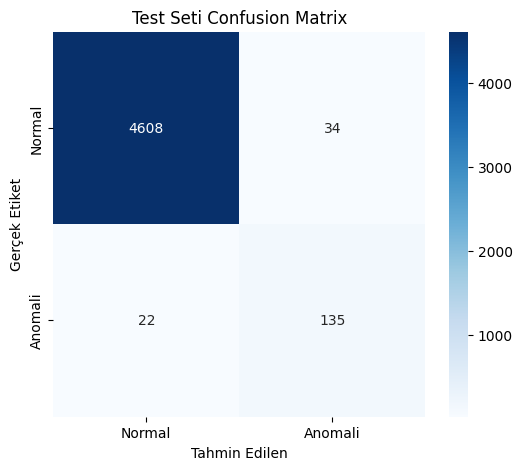

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

BATCH_SIZE = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'

splits_path = os.path.join(base_dir, 'dataset_splits.npz')
mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')
node_feat_path = os.path.join(base_dir, 'gnn_node_features.npy')
model_path = os.path.join(base_dir, 'best_f1_hybrid_model.pth') 

print(f"Model yükleniyor: {model_path}")


data = np.load(splits_path)
X_test, y_test, meta_test = data['X_test'], data['y_test'], data['meta_test']

node_features = np.load(node_feat_path)
edge_index = torch.load(edge_path)
with open(mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)

# GNN Data Objesi
class GNNData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index

gnn_data_tensor = GNNData(
    x=torch.tensor(node_features, dtype=torch.float).to(device),
    edge_index=edge_index.to(device)
)

# Segment Mapping
def map_segments(meta_data, mapping):
    indices = []
    for seg_id in meta_data[:, 1]:
        if seg_id in mapping:
            indices.append(mapping[seg_id])
        else:
            indices.append(0)
    return np.array(indices)

test_node_indices = map_segments(meta_test, segment_to_idx)

class HybridDataset(Dataset):
    def __init__(self, X, y, node_indices):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
        self.node_indices = torch.tensor(node_indices, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx], self.node_indices[idx]

test_dataset = HybridDataset(X_test, y_test, test_node_indices)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1) # Dummy head

    def forward(self, x):
        out, _ = self.lstm(x)
        last_time_step = out[:, -1, :]
        embedding = self.dropout(last_time_step)
        return None, embedding

try:
    from torch_geometric.nn import GATConv
except ImportError:
    pass # Zaten yüklü

class GATModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GATModel, self).__init__()
        self.dropout_ratio = dropout
        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)
        self.fc = nn.Linear(output_dim, 1) # Dummy head

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout_ratio, training=self.training)
        x = self.conv2(x, edge_index)
        embedding = x
        return None, embedding

class HybridAnomalyModel(nn.Module):
    def __init__(self, lstm_model, gnn_model, lstm_emb_dim=128, gnn_emb_dim=64, fusion_dim=64):
        super(HybridAnomalyModel, self).__init__()
        self.lstm_model = lstm_model
        self.gnn_model = gnn_model
        self.project_lstm = nn.Linear(lstm_emb_dim, fusion_dim)
        self.project_gnn = nn.Linear(gnn_emb_dim, fusion_dim)
        self.attention_gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, 32), nn.Tanh(), nn.Linear(32, 1), nn.Sigmoid()
        )
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x_lstm, data_gnn, current_segment_indices):
        _, emb_lstm = self.lstm_model(x_lstm)
        _, all_node_embs = self.gnn_model(data_gnn)
        emb_gnn = all_node_embs[current_segment_indices]

        proj_lstm = F.relu(self.project_lstm(emb_lstm))
        proj_gnn = F.relu(self.project_gnn(emb_gnn))

        concat_features = torch.cat([proj_lstm, proj_gnn], dim=1)
        alpha = self.attention_gate(concat_features)
        fused_vector = (alpha * proj_lstm) + ((1 - alpha) * proj_gnn)
        prediction = self.classifier(fused_vector)
        return prediction, alpha

lstm_part = LSTMModel(input_dim=4, hidden_dim=128).to(device)
gnn_part = GATModel(num_node_features=17, hidden_dim=32, output_dim=64).to(device)
hybrid_model = HybridAnomalyModel(lstm_part, gnn_part).to(device)

hybrid_model.load_state_dict(torch.load(model_path, map_location=device))
hybrid_model.eval()

print("Test seti üzerinde tahmin yapılıyor...")
all_preds = []
all_targets = []
all_alphas = []

with torch.no_grad():
    for x_batch, y_batch, idx_batch in test_loader:
        x_batch, y_batch, idx_batch = x_batch.to(device), y_batch.to(device), idx_batch.to(device)

        preds, alphas = hybrid_model(x_batch, gnn_data_tensor, idx_batch)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        all_alphas.extend(alphas.cpu().numpy())

y_true = np.array(all_targets)
y_pred_prob = np.array(all_preds)
y_pred_class = (y_pred_prob > 0.5).astype(int)

print("\n" + "="*50)
print("TEST SETİ PERFORMANS RAPORU")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_class)
print("\nConfusion Matrix:")
print(cm)
print(f"Normal (Doğru): {cm[0,0]} | Normal (Yanlış Alarm): {cm[0,1]}")
print(f"Anomali (Kaçan): {cm[1,0]} | Anomali (Yakalanan): {cm[1,1]}")

# Classification Report
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_true, y_pred_class, target_names=['Normal', 'Anomali'], digits=4))

roc_auc = roc_auc_score(y_true, y_pred_prob)
print(f"ROC-AUC Skoru: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.title('Test Seti Confusion Matrix')
plt.show()

**Deney A: Sadece LSTM (Baseline) Eğitimi**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.metrics import f1_score, accuracy_score

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 30
PATIENCE = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
splits_path = os.path.join(base_dir, 'dataset_splits.npz')
model_save_path = os.path.join(base_dir, 'best_lstm_only_model.pth')

print("Deney A (LSTM Only) Başlıyor...")

data = np.load(splits_path)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']

class LSTMDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(LSTMDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(LSTMDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (Batch, Seq, Feat)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :] 
        emb = self.dropout(last_step)
        logits = self.fc(emb)
        probs = self.sigmoid(logits)
        return probs

model = LSTMModel(input_dim=4, hidden_dim=128).to(device)

num_pos = np.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float).to(device)

def weighted_bce_loss(output, target, weight):
    epsilon = 1e-7
    output = torch.clamp(output, epsilon, 1. - epsilon)
    loss = -1 * (weight * target * torch.log(output) + (1 - target) * torch.log(1 - output))
    return loss.mean()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_f1 = 0.0
patience_counter = 0

print(f"LSTM Baseline Eğitimi Başlıyor (Pos Weight: {pos_weight.item():.2f})...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    all_train_preds = []
    all_train_targets = []

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        probs = model(x_batch)
        loss = weighted_bce_loss(probs, y_batch, pos_weight)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        all_train_preds.extend(probs.detach().cpu().numpy())
        all_train_targets.extend(y_batch.detach().cpu().numpy())

    model.eval()
    val_loss = 0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            probs = model(x_batch)
            loss = weighted_bce_loss(probs, y_batch, pos_weight)
            val_loss += loss.item()
            all_val_preds.extend(probs.cpu().numpy())
            all_val_targets.extend(y_batch.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_f1 = f1_score(all_train_targets, (np.array(all_train_preds) > 0.5).astype(int))
    val_f1 = f1_score(all_val_targets, (np.array(all_val_preds) > 0.5).astype(int))

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {avg_val_loss:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), model_save_path)
        patience_counter = 0
        print(f"  ->  New Best F1: {best_val_f1:.4f}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early Stopping.")
        break

print(f"Deney A Tamamlandı. En iyi LSTM F1 Skoru: {best_val_f1:.4f}")

Deney A (LSTM Only) Başlıyor...
LSTM Baseline Eğitimi Başlıyor (Pos Weight: 11.65)...
Epoch 1/30 | Train Loss: 0.6073 F1: 0.5226 | Val Loss: 0.4250 F1: 0.8388
  ->  New Best F1: 0.8388
Epoch 2/30 | Train Loss: 0.3829 F1: 0.8613 | Val Loss: 0.4929 F1: 0.8300
Epoch 3/30 | Train Loss: 0.3113 F1: 0.7483 | Val Loss: 0.3256 F1: 0.8187
Epoch 4/30 | Train Loss: 0.2406 F1: 0.8100 | Val Loss: 0.2430 F1: 0.7326
Epoch 5/30 | Train Loss: 0.2065 F1: 0.7770 | Val Loss: 0.2243 F1: 0.6977
Epoch 6/30 | Train Loss: 0.1965 F1: 0.7773 | Val Loss: 0.2375 F1: 0.6317
Epoch 7/30 | Train Loss: 0.1880 F1: 0.7958 | Val Loss: 0.2154 F1: 0.7484
Epoch 8/30 | Train Loss: 0.1542 F1: 0.8072 | Val Loss: 0.2079 F1: 0.7790
Epoch 9/30 | Train Loss: 0.1484 F1: 0.7888 | Val Loss: 0.1723 F1: 0.7610
Epoch 10/30 | Train Loss: 0.1262 F1: 0.8155 | Val Loss: 0.1470 F1: 0.7372
Epoch 11/30 | Train Loss: 0.1173 F1: 0.8150 | Val Loss: 0.1420 F1: 0.7456
Early Stopping.
Deney A Tamamlandı. En iyi LSTM F1 Skoru: 0.8388


LSTM Modeli yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/best_lstm_only_model.pth
Model ağırlıkları başarıyla yüklendi.
Test seti üzerinde tahmin yapılıyor...

DENEY A (LSTM ONLY) - TEST SETİ PERFORMANS RAPORU

Confusion Matrix:
[[4609   33]
 [  30  127]]
Normal (Doğru): 4609 | Normal (Yanlış Alarm): 33
Anomali (Kaçan): 30 | Anomali (Yakalanan): 127

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal     0.9935    0.9929    0.9932      4642
     Anomali     0.7937    0.8089    0.8013       157

    accuracy                         0.9869      4799
   macro avg     0.8936    0.9009    0.8972      4799
weighted avg     0.9870    0.9869    0.9869      4799

ROC-AUC Skoru: 0.8807


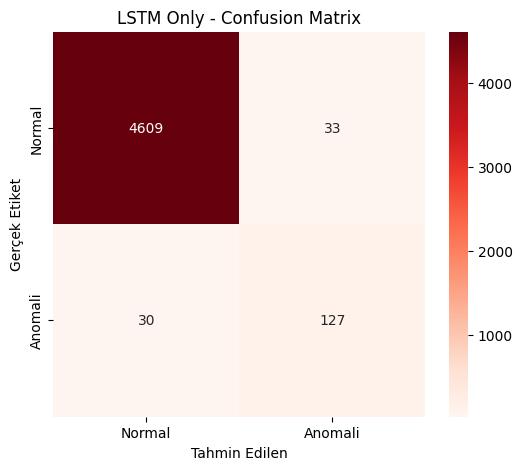

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

BATCH_SIZE = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
splits_path = os.path.join(base_dir, 'dataset_splits.npz')
model_path = os.path.join(base_dir, 'best_lstm_only_model.pth')

print(f"LSTM Modeli yükleniyor: {model_path}")

data = np.load(splits_path)
X_test, y_test = data['X_test'], data['y_test']

class LSTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader = DataLoader(LSTMDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        emb = self.dropout(last_step)
        logits = self.fc(emb)
        probs = self.sigmoid(logits)
        return probs

model = LSTMModel(input_dim=4, hidden_dim=128).to(device)
try:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Model ağırlıkları başarıyla yüklendi.")
except FileNotFoundError:
    print("HATA: Model dosyası bulunamadı! Önce eğitimi tamamladığınızdan emin olun.")

model.eval()
all_preds = []
all_targets = []

print("Test seti üzerinde tahmin yapılıyor...")
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        probs = model(x_batch)
        all_preds.extend(probs.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

y_true = np.array(all_targets)
y_pred_prob = np.array(all_preds)
y_pred_class = (y_pred_prob > 0.5).astype(int)

print("\n" + "="*50)
print("DENEY A (LSTM ONLY) - TEST SETİ PERFORMANS RAPORU")
print("="*50)

cm = confusion_matrix(y_true, y_pred_class)
print("\nConfusion Matrix:")
print(cm)
print(f"Normal (Doğru): {cm[0,0]} | Normal (Yanlış Alarm): {cm[0,1]}")
print(f"Anomali (Kaçan): {cm[1,0]} | Anomali (Yakalanan): {cm[1,1]}")

print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_true, y_pred_class, target_names=['Normal', 'Anomali'], digits=4))

try:
    roc_auc = roc_auc_score(y_true, y_pred_prob)
    print(f"ROC-AUC Skoru: {roc_auc:.4f}")
except ValueError:
    print("ROC-AUC hesaplanamadı (Sınıf hatası olabilir).")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.title('LSTM Only - Confusion Matrix')
plt.show()

Deney B (GNN Only) Başlıyor...
GNN Only Eğitimi Başlıyor (Pos Weight: 11.65)...
Epoch 1/30 | Val Loss: 1.0138 | Val F1: 0.2182
Epoch 2/30 | Val Loss: 0.9916 | Val F1: 0.2322
Epoch 3/30 | Val Loss: 1.1247 | Val F1: 0.1860
Epoch 4/30 | Val Loss: 1.0112 | Val F1: 0.2525
Epoch 5/30 | Val Loss: 1.1003 | Val F1: 0.2375
Epoch 6/30 | Val Loss: 1.0958 | Val F1: 0.2164
Epoch 7/30 | Val Loss: 1.1201 | Val F1: 0.2533
Epoch 8/30 | Val Loss: 1.1517 | Val F1: 0.2093
Epoch 9/30 | Val Loss: 1.1492 | Val F1: 0.2137
Epoch 10/30 | Val Loss: 1.1076 | Val F1: 0.2133
Epoch 11/30 | Val Loss: 1.2204 | Val F1: 0.2148
Epoch 12/30 | Val Loss: 1.1766 | Val F1: 0.2256
Epoch 13/30 | Val Loss: 1.1739 | Val F1: 0.2164
Epoch 14/30 | Val Loss: 1.1727 | Val F1: 0.2162
Epoch 15/30 | Val Loss: 1.1836 | Val F1: 0.2145
Epoch 16/30 | Val Loss: 1.1788 | Val F1: 0.2168
Epoch 17/30 | Val Loss: 1.2505 | Val F1: 0.2290
Early Stopping.

DENEY B (GNN ONLY) - TEST RAPORU

Confusion Matrix:
[[3524 1118]
 [ 103   54]]
              pre

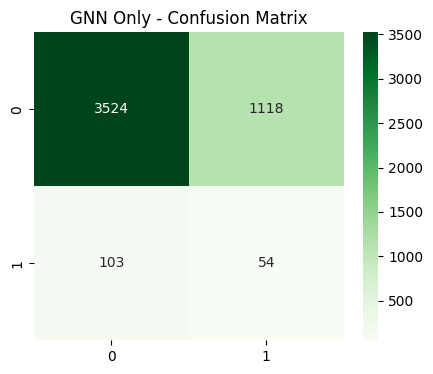

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import pickle
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 30 
PATIENCE = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
splits_path = os.path.join(base_dir, 'dataset_splits.npz')
mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')
node_feat_path = os.path.join(base_dir, 'gnn_node_features.npy')
model_save_path = os.path.join(base_dir, 'best_gnn_only_model.pth')

print("Deney B (GNN Only) Başlıyor...")

data = np.load(splits_path)
y_train, meta_train = data['y_train'], data['meta_train']
y_val, meta_val = data['y_val'], data['meta_val']
y_test, meta_test = data['y_test'], data['meta_test']

node_features = np.load(node_feat_path)
edge_index = torch.load(edge_path)

with open(mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)

class GNNData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index

gnn_data_tensor = GNNData(
    x=torch.tensor(node_features, dtype=torch.float).to(device),
    edge_index=edge_index.to(device)
)

def map_segments(meta_data, mapping):
    indices = []
    for seg_id in meta_data[:, 1]:
        if seg_id in mapping:
            indices.append(mapping[seg_id])
        else:
            indices.append(0)
    return np.array(indices)

train_node_indices = map_segments(meta_train, segment_to_idx)
val_node_indices = map_segments(meta_val, segment_to_idx)
test_node_indices = map_segments(meta_test, segment_to_idx)

class GNNOnlyDataset(Dataset):
    def __init__(self, node_indices, y):
        self.node_indices = torch.tensor(node_indices, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.node_indices[idx], self.y[idx]

train_loader = DataLoader(GNNOnlyDataset(train_node_indices, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(GNNOnlyDataset(val_node_indices, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(GNNOnlyDataset(test_node_indices, y_test), batch_size=BATCH_SIZE, shuffle=False)

try:
    from torch_geometric.nn import GATConv
except ImportError:
    pass

class GNNOnlyModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GNNOnlyModel, self).__init__()
        self.dropout_ratio = dropout

        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)

        self.classifier = nn.Sequential(
            nn.Linear(output_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, data_gnn, current_segment_indices):
        x, edge_index = data_gnn.x, data_gnn.edge_index

        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout_ratio, training=self.training)
        x = self.conv2(x, edge_index)

        batch_embeddings = x[current_segment_indices]

        probs = self.classifier(batch_embeddings)
        return probs

model = GNNOnlyModel(num_node_features=17).to(device)

num_pos = np.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float).to(device)

def weighted_bce_loss(output, target, weight):
    epsilon = 1e-7
    output = torch.clamp(output, epsilon, 1. - epsilon)
    loss = -1 * (weight * target * torch.log(output) + (1 - target) * torch.log(1 - output))
    return loss.mean()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"GNN Only Eğitimi Başlıyor (Pos Weight: {pos_weight.item():.2f})...")
best_val_f1 = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    all_train_preds = []
    all_train_targets = []

    for idx_batch, y_batch in train_loader:
        idx_batch, y_batch = idx_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        probs = model(gnn_data_tensor, idx_batch)
        loss = weighted_bce_loss(probs, y_batch, pos_weight)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        all_train_preds.extend(probs.detach().cpu().numpy())
        all_train_targets.extend(y_batch.detach().cpu().numpy())

    model.eval()
    val_loss = 0
    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():
        for idx_batch, y_batch in val_loader:
            idx_batch, y_batch = idx_batch.to(device), y_batch.to(device)
            probs = model(gnn_data_tensor, idx_batch)
            loss = weighted_bce_loss(probs, y_batch, pos_weight)
            val_loss += loss.item()
            all_val_preds.extend(probs.cpu().numpy())
            all_val_targets.extend(y_batch.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_f1 = f1_score(all_train_targets, (np.array(all_train_preds) > 0.5).astype(int))
    val_f1 = f1_score(all_val_targets, (np.array(all_val_preds) > 0.5).astype(int))

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), model_save_path)
        patience_counter = 0
      
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early Stopping.")
        break

print("\n" + "="*50)
print("DENEY B (GNN ONLY) - TEST RAPORU")
print("="*50)

model.load_state_dict(torch.load(model_save_path))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for idx_batch, y_batch in test_loader:
        idx_batch, y_batch = idx_batch.to(device), y_batch.to(device)
        probs = model(gnn_data_tensor, idx_batch)
        all_preds.extend(probs.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

y_true = np.array(all_targets)
y_pred_prob = np.array(all_preds)
y_pred_class = (y_pred_prob > 0.5).astype(int)

# Rapor
cm = confusion_matrix(y_true, y_pred_class)
print("\nConfusion Matrix:")
print(cm)
print(classification_report(y_true, y_pred_class, target_names=['Normal', 'Anomali'], digits=4))
print(f"ROC-AUC Skoru: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Görselleştirme
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('GNN Only - Confusion Matrix')
plt.show()

Grafik çizimi için veriler ve modeller hazırlanıyor...
Modeller yükleniyor...
Hybrid Model yüklenemedi: Error(s) in loading state_dict for HybridAnomalyModel:
	Unexpected key(s) in state_dict: "gnn_model.fc.weight", "gnn_model.fc.bias". 
LSTM Only için tahmin yapılıyor...
GNN Only için tahmin yapılıyor...


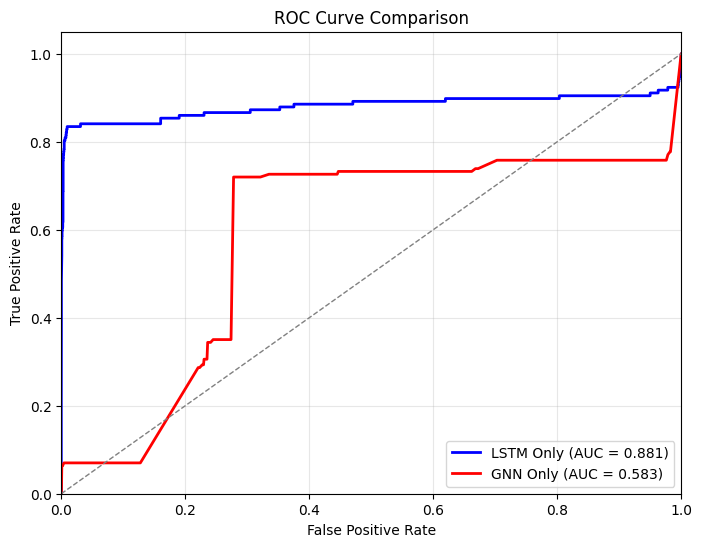

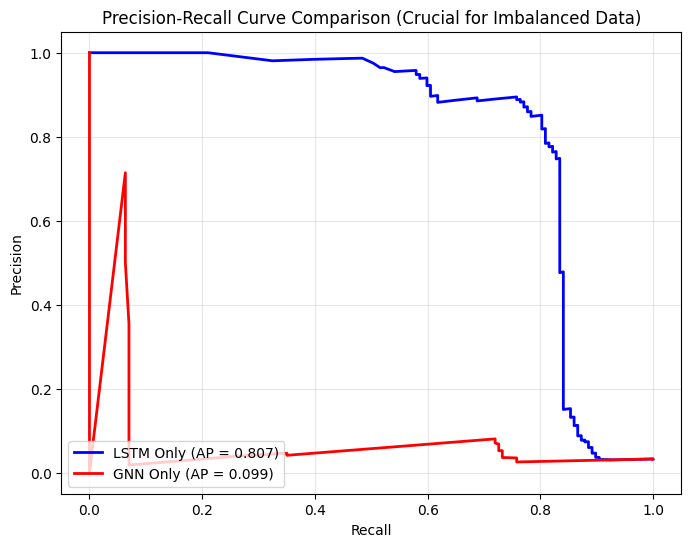

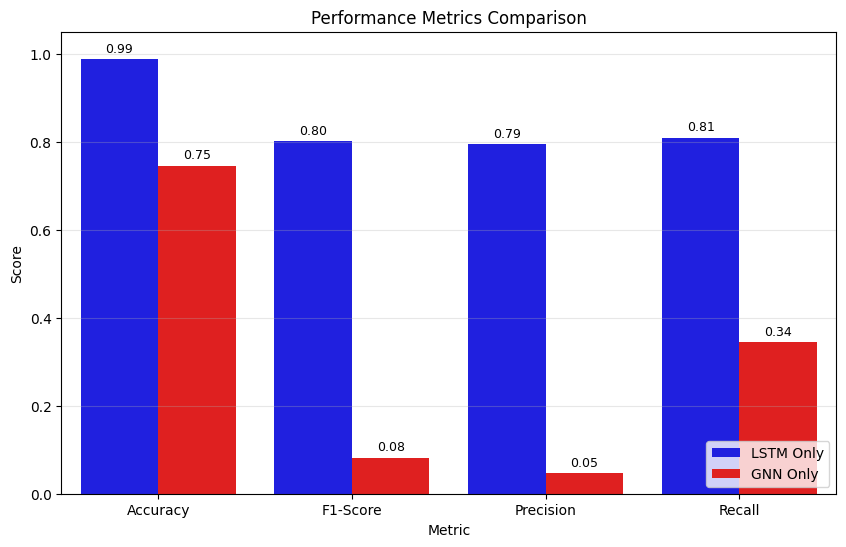

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, accuracy_score, precision_score, recall_score

BATCH_SIZE = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'

splits_path = os.path.join(base_dir, 'dataset_splits.npz')
mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')
node_feat_path = os.path.join(base_dir, 'gnn_node_features.npy')

path_hybrid = os.path.join(base_dir, 'best_f1_hybrid_model.pth')
path_lstm = os.path.join(base_dir, 'best_lstm_only_model.pth')
path_gnn = os.path.join(base_dir, 'best_gnn_only_model.pth')

print("Grafik çizimi için veriler ve modeller hazırlanıyor...")

data = np.load(splits_path)
X_test, y_test, meta_test = data['X_test'], data['y_test'], data['meta_test']
node_features = np.load(node_feat_path)
edge_index = torch.load(edge_path)
with open(mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)

class GNNData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index
gnn_data_tensor = GNNData(
    x=torch.tensor(node_features, dtype=torch.float).to(device),
    edge_index=edge_index.to(device)
)

def map_segments(meta_data, mapping):
    indices = []
    for seg_id in meta_data[:, 1]:
        indices.append(mapping.get(seg_id, 0))
    return np.array(indices)
test_node_indices = map_segments(meta_test, segment_to_idx)

class EvalDataset(Dataset):
    def __init__(self, X, y, node_indices):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
        self.node_indices = torch.tensor(node_indices, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx], self.node_indices[idx]

test_loader = DataLoader(EvalDataset(X_test, y_test, test_node_indices), batch_size=BATCH_SIZE, shuffle=False)

class LSTMModel_Only(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel_Only, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        probs = self.sigmoid(self.fc(self.dropout(out[:, -1, :])))
        return probs

try: from torch_geometric.nn import GATConv
except: pass
class GNNOnlyModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GNNOnlyModel, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)
        self.classifier = nn.Sequential(nn.Linear(output_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, data_gnn, current_segment_indices):
        x, edge_index = data_gnn.x, data_gnn.edge_index
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        probs = self.classifier(x[current_segment_indices])
        return probs

class LSTMModel_Part(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel_Part, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return None, self.dropout(out[:, -1, :])

class GATModel_Part(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GATModel_Part, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return None, x

class HybridAnomalyModel(nn.Module):
    def __init__(self, lstm_model, gnn_model, lstm_emb_dim=128, gnn_emb_dim=64, fusion_dim=64):
        super(HybridAnomalyModel, self).__init__()
        self.lstm_model = lstm_model
        self.gnn_model = gnn_model
        self.project_lstm = nn.Linear(lstm_emb_dim, fusion_dim)
        self.project_gnn = nn.Linear(gnn_emb_dim, fusion_dim)
        self.attention_gate = nn.Sequential(nn.Linear(fusion_dim * 2, 32), nn.Tanh(), nn.Linear(32, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x_lstm, data_gnn, current_segment_indices):
        _, emb_lstm = self.lstm_model(x_lstm)
        _, all_node_embs = self.gnn_model(data_gnn)
        emb_gnn = all_node_embs[current_segment_indices]
        proj_lstm = F.relu(self.project_lstm(emb_lstm))
        proj_gnn = F.relu(self.project_gnn(emb_gnn))
        concat_features = torch.cat([proj_lstm, proj_gnn], dim=1)
        alpha = self.attention_gate(concat_features)
        fused_vector = (alpha * proj_lstm) + ((1 - alpha) * proj_gnn)
        return self.classifier(fused_vector), alpha

print("Modeller yükleniyor...")
models = {}

try:
    m_lstm = LSTMModel_Only(input_dim=4, hidden_dim=128).to(device)
    m_lstm.load_state_dict(torch.load(path_lstm, map_location=device))
    m_lstm.eval()
    models['LSTM Only'] = m_lstm
except Exception as e: print(f"LSTM Model yüklenemedi: {e}")

try:
    m_gnn = GNNOnlyModel(num_node_features=17).to(device)
    m_gnn.load_state_dict(torch.load(path_gnn, map_location=device))
    m_gnn.eval()
    models['GNN Only'] = m_gnn
except Exception as e: print(f"GNN Model yüklenemedi: {e}")

try:
    l_part = LSTMModel_Part(input_dim=4, hidden_dim=128).to(device)
    g_part = GATModel_Part(num_node_features=17, hidden_dim=32, output_dim=64).to(device)
    m_hybrid = HybridAnomalyModel(l_part, g_part).to(device)
    m_hybrid.load_state_dict(torch.load(path_hybrid, map_location=device))
    m_hybrid.eval()
    models['Hybrid (Proposed)'] = m_hybrid
except Exception as e: print(f"Hybrid Model yüklenemedi: {e}")

results = {}
y_true = []
for _, y_b, _ in test_loader: y_true.extend(y_b.numpy())
y_true = np.array(y_true).flatten()

for name, model in models.items():
    print(f"{name} için tahmin yapılıyor...")
    preds = []
    with torch.no_grad():
        for x_b, _, idx_b in test_loader:
            x_b, idx_b = x_b.to(device), idx_b.to(device)
            if name == 'LSTM Only':
                out = model(x_b)
            elif name == 'GNN Only':
                out = model(gnn_data_tensor, idx_b)
            else: # Hybrid
                out, _ = model(x_b, gnn_data_tensor, idx_b)
            preds.extend(out.cpu().numpy())
    results[name] = np.array(preds).flatten()


plt.figure(figsize=(8, 6))
colors = {'LSTM Only': 'blue', 'GNN Only': 'red', 'Hybrid (Proposed)': 'green'}
for name, y_scores in results.items():
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
for name, y_scores in results.items():
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)
    plt.plot(recall, precision, color=colors[name], lw=2, label=f'{name} (AP = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison (Crucial for Imbalanced Data)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

metrics_data = []
for name, y_scores in results.items():
    y_pred = (y_scores > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    metrics_data.append([name, acc, f1, prec, rec])

import pandas as pd
df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'F1-Score', 'Precision', 'Recall'])
df_melted = df_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette=colors)
plt.title('Performance Metrics Comparison')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, fontsize=9)
plt.show()

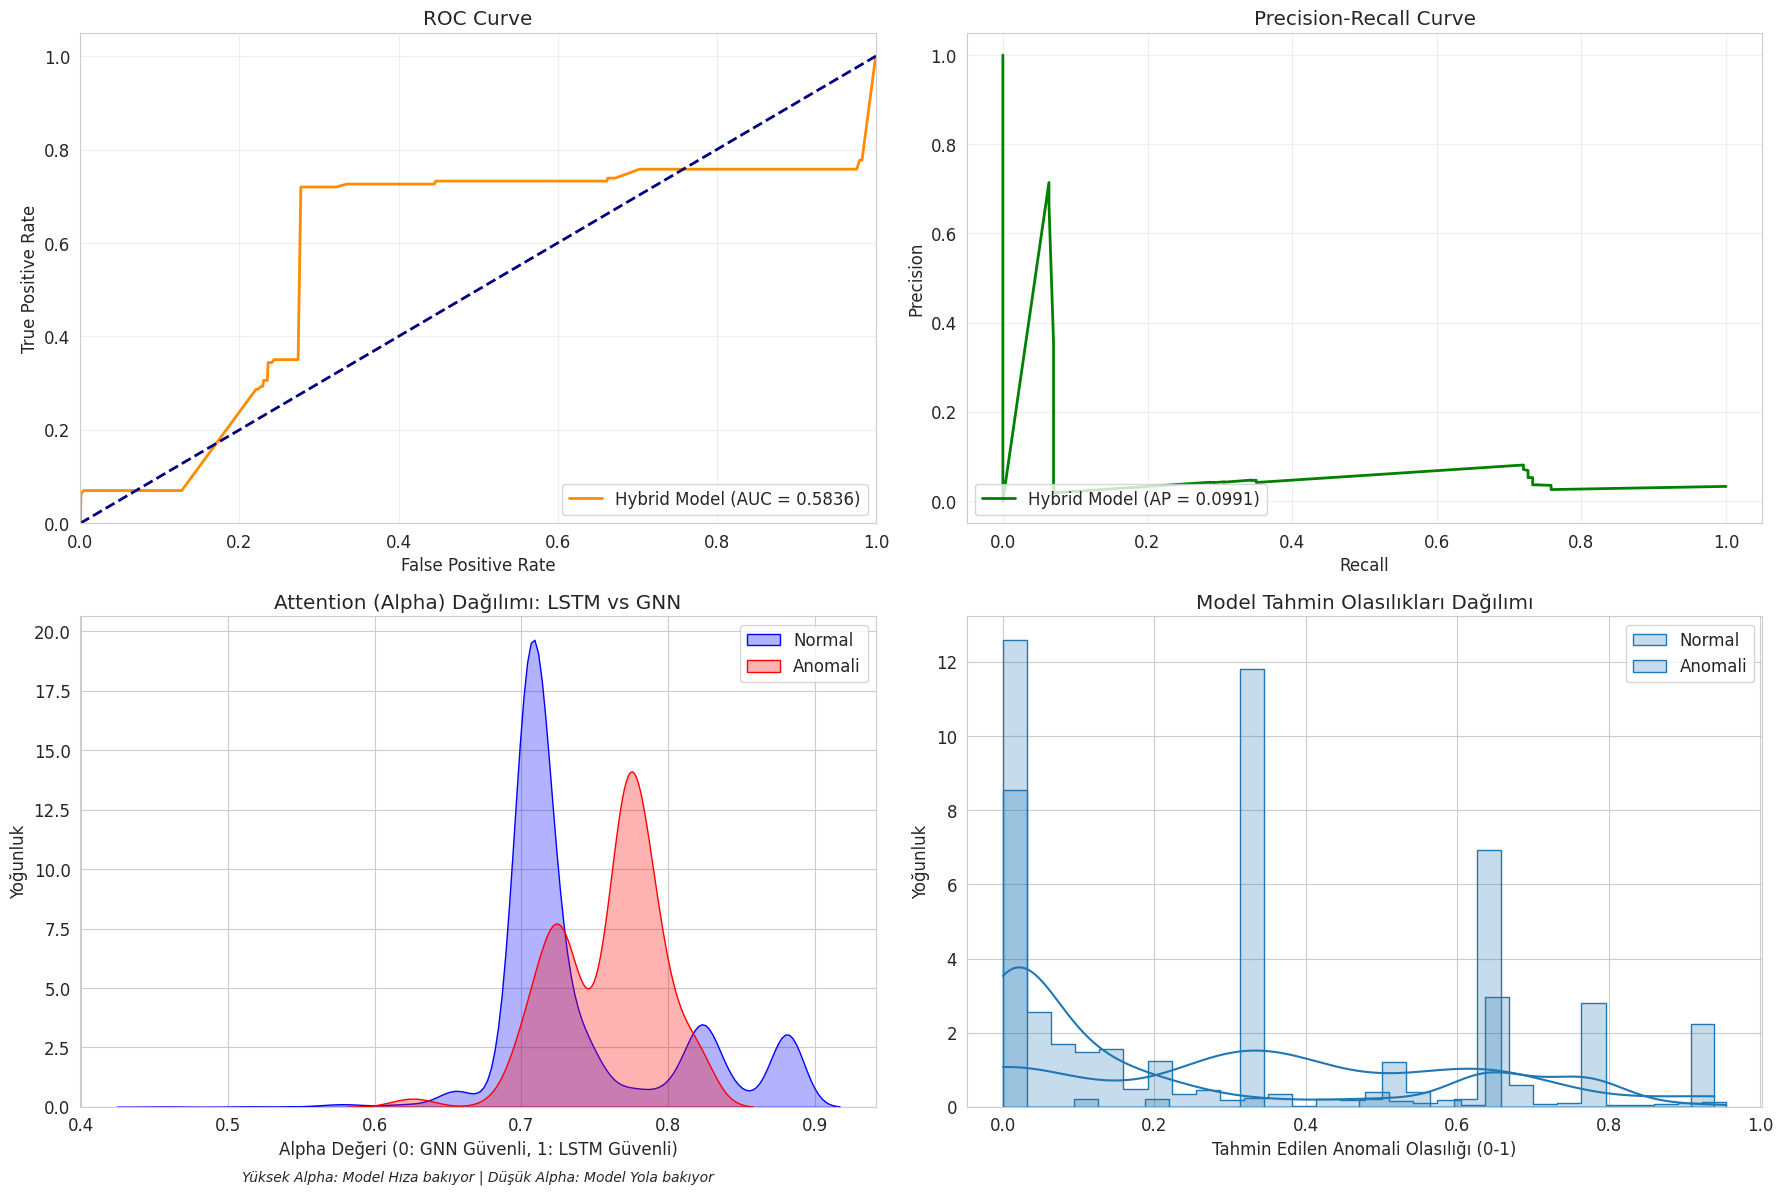

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np


alphas = np.array(all_alphas).flatten()

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(2, 2, 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'Hybrid Model (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
pr_auc = average_precision_score(y_true, y_pred_prob)

ax2.plot(recall, precision, color='green', lw=2, label=f'Hybrid Model (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)


ax3 = plt.subplot(2, 2, 3)

alphas_normal = alphas[y_true == 0]
alphas_anomaly = alphas[y_true == 1]

sns.kdeplot(alphas_normal, fill=True, color="blue", label='Normal', ax=ax3, alpha=0.3)
sns.kdeplot(alphas_anomaly, fill=True, color="red", label='Anomali', ax=ax3, alpha=0.3)

ax3.set_title('Attention (Alpha) Dağılımı: LSTM vs GNN')
ax3.set_xlabel('Alpha Değeri (0: GNN Güvenli, 1: LSTM Güvenli)')
ax3.set_ylabel('Yoğunluk')
ax3.legend()
ax3.text(0.5, -0.15, "Yüksek Alpha: Model Hıza bakıyor | Düşük Alpha: Model Yola bakıyor",
         transform=ax3.transAxes, ha='center', fontsize=10, style='italic')


ax4 = plt.subplot(2, 2, 4)

preds_normal = y_pred_prob[y_true == 0]
preds_anomaly = y_pred_prob[y_true == 1]

sns.histplot(preds_normal, color="blue", label='Normal', kde=True, bins=30, ax=ax4, stat="density", element="step")
sns.histplot(preds_anomaly, color="red", label='Anomali', kde=True, bins=30, ax=ax4, stat="density", element="step")

ax4.set_title('Model Tahmin Olasılıkları Dağılımı')
ax4.set_xlabel('Tahmin Edilen Anomali Olasılığı (0-1)')
ax4.set_ylabel('Yoğunluk')
ax4.legend()

plt.tight_layout()
plt.show()

Feature Importance analizi için hazırlık yapılıyor...
Model başarıyla yüklendi!
Orijinal F1 Skoru hesaplanıyor...
Baseline F1 Score: 0.8359
LSTM özelliklerinin önemi ölçülüyor...
  -> Speed: F1 düşüşü 0.7046
  -> Acceleration: F1 düşüşü 0.7547
  -> Bearing Sin: F1 düşüşü 0.0062
  -> Bearing Cos: F1 düşüşü 0.0113
GNN özelliklerinin önemi ölçülüyor...
  -> Length: F1 düşüşü 0.0026
  -> MaxSpeed: F1 düşüşü 0.0113
  -> Rarity: F1 düşüşü -0.0020
  -> Betweenness: F1 düşüşü 0.0026
  -> Closeness: F1 düşüşü 0.0000
  -> Degree: F1 düşüşü 0.0026
  -> Lanes: F1 düşüşü 0.0000
  -> Tunnel: F1 düşüşü 0.0000
  -> TrafficLight: F1 düşüşü 0.0088


/tmp/ipython-input-3847811813.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_names, palette=colors)


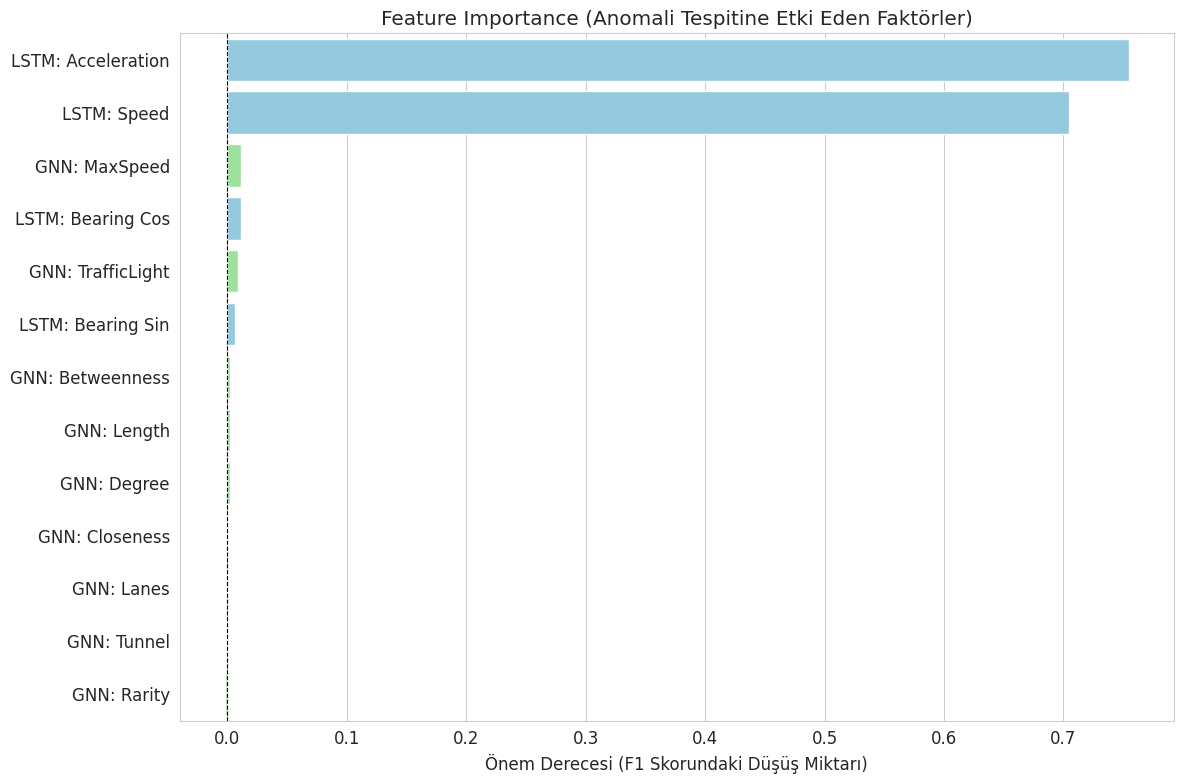

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

BATCH_SIZE = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'

splits_path = os.path.join(base_dir, 'dataset_splits.npz')
mapping_path = os.path.join(base_dir, 'segment_mapping.pkl')
edge_path = os.path.join(base_dir, 'gnn_edge_index.pt')
node_feat_path = os.path.join(base_dir, 'gnn_node_features.npy')
model_path = os.path.join(base_dir, 'best_f1_hybrid_model.pth')

print("Feature Importance analizi için hazırlık yapılıyor...")

data = np.load(splits_path)
X_test, y_test, meta_test = data['X_test'], data['y_test'], data['meta_test']
node_features = np.load(node_feat_path)
edge_index = torch.load(edge_path)
with open(mapping_path, 'rb') as f:
    segment_to_idx = pickle.load(f)

class GNNData:
    def __init__(self, x, edge_index):
        self.x = x
        self.edge_index = edge_index
gnn_data_tensor = GNNData(
    x=torch.tensor(node_features, dtype=torch.float).to(device),
    edge_index=edge_index.to(device)
)

def map_segments(meta_data, mapping):
    indices = []
    for seg_id in meta_data[:, 1]:
        indices.append(mapping.get(seg_id, 0))
    return np.array(indices)
test_node_indices = map_segments(meta_test, segment_to_idx)


class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return None, self.dropout(out[:, -1, :])

try: from torch_geometric.nn import GATConv
except: pass

class GATModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return None, x

class HybridAnomalyModel(nn.Module):
    def __init__(self, lstm_model, gnn_model, lstm_emb_dim=128, gnn_emb_dim=64, fusion_dim=64):
        super(HybridAnomalyModel, self).__init__()
        self.lstm_model = lstm_model
        self.gnn_model = gnn_model
        self.project_lstm = nn.Linear(lstm_emb_dim, fusion_dim)
        self.project_gnn = nn.Linear(gnn_emb_dim, fusion_dim)
        self.attention_gate = nn.Sequential(nn.Linear(fusion_dim * 2, 32), nn.Tanh(), nn.Linear(32, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x_lstm, data_gnn, current_segment_indices):
        _, emb_lstm = self.lstm_model(x_lstm)
        _, all_node_embs = self.gnn_model(data_gnn)
        emb_gnn = all_node_embs[current_segment_indices]

        proj_lstm = F.relu(self.project_lstm(emb_lstm))
        proj_gnn = F.relu(self.project_gnn(emb_gnn))

        concat_features = torch.cat([proj_lstm, proj_gnn], dim=1)
        alpha = self.attention_gate(concat_features)
        fused_vector = (alpha * proj_lstm) + ((1 - alpha) * proj_gnn)
        return self.classifier(fused_vector), alpha

lstm_part = LSTMModel(input_dim=4, hidden_dim=128).to(device)
gnn_part = GATModel(num_node_features=17, hidden_dim=32, output_dim=64).to(device)
model = HybridAnomalyModel(lstm_part, gnn_part).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model başarıyla yüklendi!")


lstm_feat_names = ['Speed', 'Acceleration', 'Bearing Sin', 'Bearing Cos']
gnn_feat_names = ['Length', 'MaxSpeed', 'Rarity', 'Betweenness', 'Closeness', 'Degree', 'Lanes', 'Tunnel', 'TrafficLight']

class Dataset_Wrapper(Dataset):
    def __init__(self, X, y, idx):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.float).unsqueeze(1)
        self.idx = torch.tensor(idx, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i], self.idx[i]

def get_score(X_in, nodes_in, y_in):
    ds = Dataset_Wrapper(X_in, y_in, nodes_in)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    preds = []
    with torch.no_grad():
        for x_b, _, idx_b in dl:
            x_b, idx_b = x_b.to(device), idx_b.to(device)
            out, _ = model(x_b, gnn_data_tensor, idx_b)
            preds.extend(out.cpu().numpy())
    y_pred = (np.array(preds) > 0.5).astype(int)
    return f1_score(y_in, y_pred)

print("Orijinal F1 Skoru hesaplanıyor...")
original_f1 = get_score(X_test, test_node_indices, y_test)
print(f"Baseline F1 Score: {original_f1:.4f}")

importances = {}

print("LSTM özelliklerinin önemi ölçülüyor...")
for i, name in enumerate(lstm_feat_names):
    X_temp = X_test.copy()
    np.random.shuffle(X_temp[:, :, i])
    new_f1 = get_score(X_temp, test_node_indices, y_test)
    drop = original_f1 - new_f1
    importances[f"LSTM: {name}"] = drop
    print(f"  -> {name}: F1 düşüşü {drop:.4f}")

original_node_features = node_features.copy()
print("GNN özelliklerinin önemi ölçülüyor...")

for i, name in enumerate(gnn_feat_names):
    node_feat_temp = original_node_features.copy()
    np.random.shuffle(node_feat_temp[:, i])

    gnn_data_temp = GNNData(
        x=torch.tensor(node_feat_temp, dtype=torch.float).to(device),
        edge_index=edge_index.to(device)
    )

    gnn_data_save = gnn_data_tensor
    gnn_data_tensor = gnn_data_temp

    new_f1 = get_score(X_test, test_node_indices, y_test)
    drop = original_f1 - new_f1
    importances[f"GNN: {name}"] = drop
    print(f"  -> {name}: F1 düşüşü {drop:.4f}")

    gnn_data_tensor = gnn_data_save

names = list(importances.keys())
values = list(importances.values())

sorted_indices = np.argsort(values)[::-1]
sorted_names = [names[i] for i in sorted_indices]
sorted_values = [values[i] for i in sorted_indices]

plt.figure(figsize=(12, 8))
colors = ['skyblue' if 'LSTM' in n else 'lightgreen' for n in sorted_names]
sns.barplot(x=sorted_values, y=sorted_names, palette=colors)
plt.title('Feature Importance (Anomali Tespitine Etki Eden Faktörler)')
plt.xlabel('Önem Derecesi (F1 Skorundaki Düşüş Miktarı)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

**🚀 Adım 4.2.2: Case Study (Vaka Analizi)**

Hibrit Model yükleniyor: /content/drive/MyDrive/Colab Notebooks/veriseti/best_f1_hybrid_model.pth
✅ Model başarıyla yüklendi (Hazır).
Uygun bir Trip aranıyor (True Positive)...
CASE STUDY İÇİN SEÇİLEN SÜRÜŞ: Trip ID 23


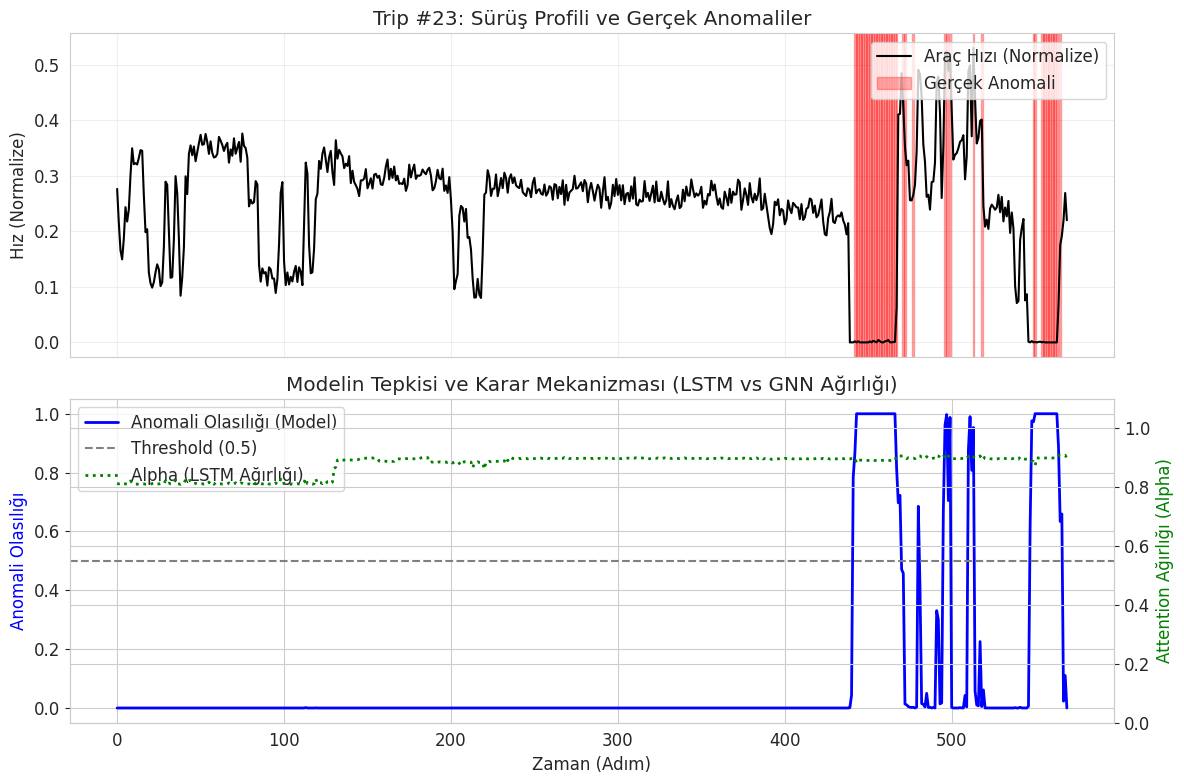

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
model_path = os.path.join(base_dir, 'best_f1_hybrid_model.pth') 



class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1) 
    def forward(self, x):
        out, _ = self.lstm(x)
        return None, self.dropout(out[:, -1, :])

try: from torch_geometric.nn import GATConv
except: pass

class GATModel(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, output_dim=64, num_heads=2, dropout=0.2):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_dim, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * num_heads, output_dim, heads=1, concat=False, dropout=dropout)
        self.fc = nn.Linear(output_dim, 1) 
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return None, x

class HybridAnomalyModel(nn.Module):
    def __init__(self, lstm_model, gnn_model, lstm_emb_dim=128, gnn_emb_dim=64, fusion_dim=64):
        super(HybridAnomalyModel, self).__init__()
        self.lstm_model = lstm_model
        self.gnn_model = gnn_model
        self.project_lstm = nn.Linear(lstm_emb_dim, fusion_dim)
        self.project_gnn = nn.Linear(gnn_emb_dim, fusion_dim)
        self.attention_gate = nn.Sequential(nn.Linear(fusion_dim * 2, 32), nn.Tanh(), nn.Linear(32, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x_lstm, data_gnn, current_segment_indices):
        _, emb_lstm = self.lstm_model(x_lstm)
        _, all_node_embs = self.gnn_model(data_gnn)
        emb_gnn = all_node_embs[current_segment_indices]

        proj_lstm = F.relu(self.project_lstm(emb_lstm))
        proj_gnn = F.relu(self.project_gnn(emb_gnn))

        concat_features = torch.cat([proj_lstm, proj_gnn], dim=1)
        alpha = self.attention_gate(concat_features)
        fused_vector = (alpha * proj_lstm) + ((1 - alpha) * proj_gnn)
        prediction = self.classifier(fused_vector)
        return prediction, alpha

# --- 2. DOĞRU MODELİ YÜKLE ---
print(f"Hibrit Model yükleniyor: {model_path}")
lstm_part = LSTMModel(input_dim=4, hidden_dim=128).to(device)
gnn_part = GATModel(num_node_features=17, hidden_dim=32, output_dim=64).to(device)
hybrid_model = HybridAnomalyModel(lstm_part, gnn_part).to(device)

try:
    hybrid_model.load_state_dict(torch.load(model_path, map_location=device))
    hybrid_model.eval()
    print("Model başarıyla yüklendi (Hazır).")
except Exception as e:
    print(f" Model yükleme hatası: {e}")


def find_best_case_study(loader, model, meta_data):
    model.eval()

    unique_trips = np.unique(meta_data[:, 0])

    print("Uygun bir Trip aranıyor (True Positive)...")

    all_X = []
    all_y = []
    all_indices = []

    with torch.no_grad():
        for x_b, y_b, idx_b in loader:
            all_X.append(x_b)
            all_y.append(y_b)
            all_indices.append(idx_b)

    X_tensor = torch.cat(all_X)
    y_tensor = torch.cat(all_y)
    indices_tensor = torch.cat(all_indices)

    y_true = y_tensor.cpu().numpy().flatten()

    for trip_id in unique_trips:
        trip_mask = (meta_data[:, 0] == trip_id)

        if np.sum(y_true[trip_mask]) == 0:
            continue

        batch_X = X_tensor[trip_mask].to(device)
        batch_idx = indices_tensor[trip_mask].to(device)
        batch_y = y_true[trip_mask]

        with torch.no_grad():
            preds, alphas = model(batch_X, gnn_data_tensor, batch_idx)
            probs = preds.cpu().numpy().flatten()

        anomaly_indices = np.where(batch_y == 1)[0]
        if len(anomaly_indices) > 0:
            caught_anomalies = probs[anomaly_indices]
            if np.max(caught_anomalies) > 0.80:
                if len(batch_y) > 30:
                    return trip_id, batch_X, batch_idx, batch_y, probs, alphas.cpu().numpy().flatten(), trip_mask

    return None

if 'test_loader' not in locals():
    print("UYARI: test_loader tanımlı değil! Lütfen Veri Yükleme bloğunu çalıştırın.")
else:
    result = find_best_case_study(test_loader, hybrid_model, meta_test)

    if result is None:
        print("Uygun bir anomali örneği bulunamadı (Filtreleri gevşetin).")
    else:
        trip_id, X_data, idx_data, y_true_trip, y_prob_trip, alpha_trip, mask = result
        print(f"CASE STUDY İÇİN SEÇİLEN SÜRÜŞ: Trip ID {int(trip_id)}")

        speed_norm = X_data[:, -1, 0].cpu().numpy()

        time_axis = np.arange(len(speed_norm))

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        ax1.plot(time_axis, speed_norm, color='black', label='Araç Hızı (Normalize)', linewidth=1.5)

        for i in range(len(y_true_trip)):
            if y_true_trip[i] == 1:
                lbl = 'Gerçek Anomali' if i == np.where(y_true_trip==1)[0][0] else ""
                ax1.axvspan(i-0.5, i+0.5, color='red', alpha=0.3, label=lbl)

        ax1.set_ylabel('Hız (Normalize)')
        ax1.set_title(f'Trip #{int(trip_id)}: Sürüş Profili ve Gerçek Anomaliler')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        ax2.plot(time_axis, y_prob_trip, color='blue', label='Anomali Olasılığı (Model)', linewidth=2)
        ax2.axhline(y=0.5, color='gray', linestyle='--', label='Threshold (0.5)')

        ax2_right = ax2.twinx()
        ax2_right.plot(time_axis, alpha_trip, color='green', linestyle=':', label='Alpha (LSTM Ağırlığı)', linewidth=2)
        ax2_right.set_ylabel('Attention Ağırlığı (Alpha)', color='green')
        ax2_right.set_ylim(0, 1.1)

        ax2.set_xlabel('Zaman (Adım)')
        ax2.set_ylabel('Anomali Olasılığı', color='blue')

        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_right.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        plt.title(f'Modelin Tepkisi ve Karar Mekanizması (LSTM vs GNN Ağırlığı)')
        plt.tight_layout()
        plt.show()

Loading data...
Extracting coordinates from 'coords' column...
Preparing data for Trip #23...
Plotting 5747 data points...


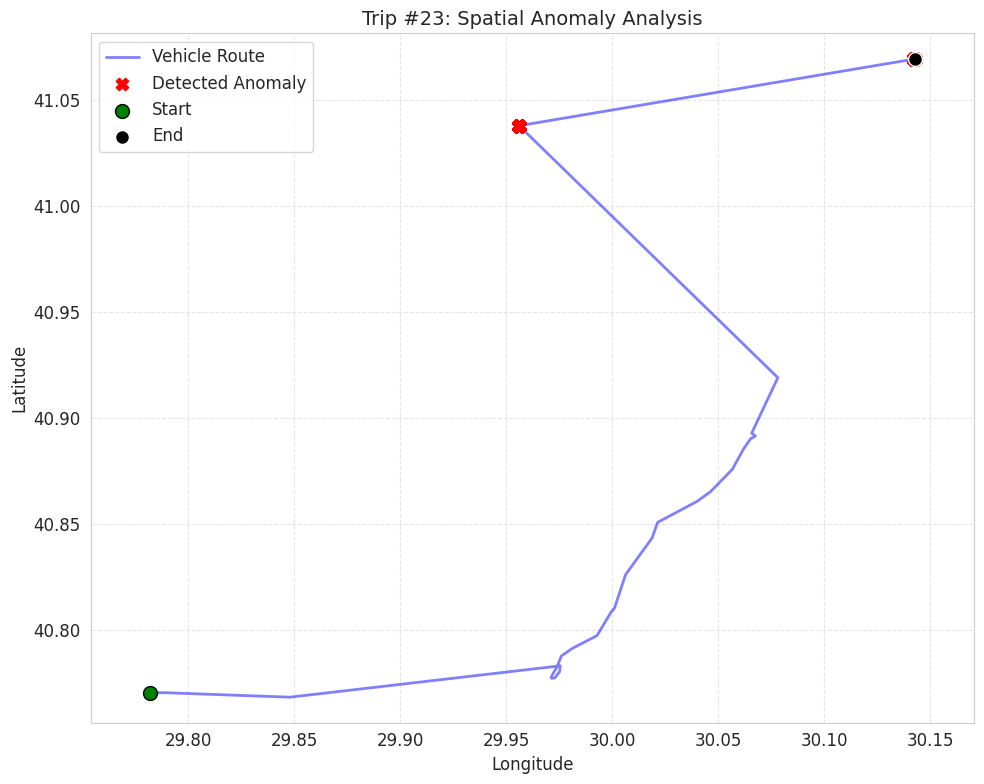

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re 
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
lstm_path = os.path.join(base_dir, 'lstm_data_cleaned_step2.csv')
gnn_path = os.path.join(base_dir, 'GNN_DATA.csv')

print("Loading data...")
df_trip = pd.read_csv(lstm_path)
df_gnn = pd.read_csv(gnn_path)

print("Extracting coordinates from 'coords' column...")

def parse_coordinates(coord_str):
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(coord_str))

    if len(nums) >= 2:
        lon = float(nums[0])
        lat = float(nums[1])
        return lat, lon
    return None, None

df_gnn[['lat', 'lon']] = df_gnn['coords'].apply(lambda x: pd.Series(parse_coordinates(x)))

TARGET_TRIP_ID = 23
print(f"Preparing data for Trip #{TARGET_TRIP_ID}...")

my_trip = df_trip[df_trip['trip_id'] == TARGET_TRIP_ID].copy().sort_values('time')

gnn_coords = df_gnn[['segment_id', 'lat', 'lon']].drop_duplicates(subset=['segment_id'])

my_trip_mapped = pd.merge(my_trip, gnn_coords, on='segment_id', how='left')

my_trip_mapped = my_trip_mapped.dropna(subset=['lat', 'lon'])

print(f"Plotting {len(my_trip_mapped)} data points...")

plt.figure(figsize=(10, 8))

plt.plot(my_trip_mapped['lon'], my_trip_mapped['lat'],
         color='blue', alpha=0.5, linewidth=2, label='Vehicle Route', zorder=1)

anomalies = my_trip_mapped[my_trip_mapped['anomaly_binary'] == 1]
if len(anomalies) > 0:
    plt.scatter(anomalies['lon'], anomalies['lat'],
                color='red', s=80, label='Detected Anomaly', zorder=2, marker='X')
else:
    print("No anomalies found for this trip.")

if len(my_trip_mapped) > 0:
    plt.scatter(my_trip_mapped.iloc[0]['lon'], my_trip_mapped.iloc[0]['lat'],
                c='green', s=100, label='Start', edgecolors='black', zorder=3)
    plt.scatter(my_trip_mapped.iloc[-1]['lon'], my_trip_mapped.iloc[-1]['lat'],
                c='black', s=100, label='End', edgecolors='white', zorder=3)

plt.title(f'Trip #{TARGET_TRIP_ID}: Spatial Anomaly Analysis', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/drive/MyDrive/Colab Notebooks/veriseti/'
output_csv_path = os.path.join(base_dir, 'anomaly_results.csv')


print("Sonuç CSV dosyası oluşturuluyor...")

all_probs = []
all_targets = []
all_alphas = []

hybrid_model.eval()

with torch.no_grad():
    for x_b, y_b, idx_b in test_loader:
        x_b, idx_b = x_b.to(device), idx_b.to(device)

        preds, alphas = hybrid_model(x_b, gnn_data_tensor, idx_b)

        all_probs.extend(preds.cpu().numpy().flatten())
        all_targets.extend(y_b.cpu().numpy().flatten())
        all_alphas.extend(alphas.cpu().numpy().flatten())

df_results = pd.DataFrame({
    'true_label': all_targets,
    'anomaly_score': all_probs,
    'attention_alpha': all_alphas 
})

df_results['predicted_label'] = (df_results['anomaly_score'] > 0.5).astype(int)

df_results.to_csv(output_csv_path, index=False)
print(f"✅ anomaly_results.csv kaydedildi: {output_csv_path}")
print(df_results.head())

Sonuç CSV dosyası oluşturuluyor...
✅ anomaly_results.csv kaydedildi: /content/drive/MyDrive/Colab Notebooks/veriseti/anomaly_results.csv
   true_label  anomaly_score  attention_alpha  predicted_label
0         0.0       0.008693         0.885849                0
1         0.0       0.005485         0.850251                0
2         0.0       0.000157         0.882630                0
3         0.0       0.000079         0.884504                0
4         0.0       0.000074         0.886642                0
